In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b


In [4]:
from langgraph.prebuilt import ToolNode


tool_list = [add, multiply]
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [5]:
ai_message = llm_with_tools.invoke("what is 2 + 3?")

In [6]:
ai_message

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 75, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DGlepyjYYQ48FdumS5tyQdhLMxD1b', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cc868-7342-70b1-b4ec-6ed1bf0b2cf1-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 3}, 'id': 'call_7CfwmejIb0d7kzD1q9pYaAba', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 17, 'total_tokens': 92, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [7]:
tool_node.invoke({"messages": [ai_message]}, {"configurable": {}})

ValueError: Missing required config key 'N/A' for 'tools'.

In [8]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [ ]:
def agent(state: MessagesState):
    response =state['messages']
    response = llm_with_tools.invoke(response)
    return {"messages": [response]}
    

    

In [10]:
def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return 'end'


In [11]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)




In [16]:
from langgraph.graph import START , END


graph_builder.add_edge(START, 'agent')

graph_builder.add_conditional_edges('agent', should_continue,
 {'tools': 'tools',
 'end': END
 }) 


graph_builder.add_edge('tools', 'agent')

In [17]:
graph = graph_builder.compile()

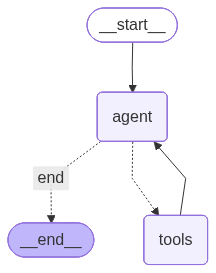

In [18]:
from IPython.display  import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
from langchain_core.messages import HumanMessage

for chunk in graph.stream({"messages": [HumanMessage(content="3에다 5를 더하고 거기에 8을 곱하면?")]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

3에다 5를 더하고 거기에 8을 곱하면?
================================== Ai Message ==================================
Tool Calls:
  add (call_efJBHq0NB85QoTzygHUbELBd)
 Call ID: call_efJBHq0NB85QoTzygHUbELBd
  Args:
    a: 3
    b: 5
  multiply (call_igb0MuJJBkCkRh0yfDJD3i4a)
 Call ID: call_igb0MuJJBkCkRh0yfDJD3i4a
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: multiply

40
================================== Ai Message ==================================
Tool Calls:
  multiply (call_OKuCjsMh9fiqgEaW0IDR2Nf5)
 Call ID: call_OKuCjsMh9fiqgEaW0IDR2Nf5
  Args:
    a: 8
    b: 8
================================= Tool Message =================================
Name: multiply

64
================================== Ai Message ==================================

3에 5를 더하면 8이 되고, 그에 8을 곱하면 64입니다.
